In [2]:
import pandas as pd

df = pd.read_csv("data/train_essays.csv")

print(df.head())

print("\nShape:", df.shape)

print("\nColumns:")
print(df.columns)

         id  prompt_id                                               text  \
0  0059830c          0  Cars. Cars have been around since they became ...   
1  005db917          0  Transportation is a large necessity in most co...   
2  008f63e3          0  "America's love affair with it's vehicles seem...   
3  00940276          0  How often do you ride in a car? Do you drive a...   
4  00c39458          0  Cars are a wonderful thing. They are perhaps o...   

   generated  
0          0  
1          0  
2          0  
3          0  
4          0  

Shape: (1378, 4)

Columns:
Index(['id', 'prompt_id', 'text', 'generated'], dtype='object')


In [3]:
print(df.isnull().sum())

print(df['generated'].value_counts())

id           0
prompt_id    0
text         0
generated    0
dtype: int64
generated
0    1375
1       3
Name: count, dtype: int64


In [4]:
human_df = df[df['generated'] == 0]

print(human_df.shape)

(1375, 4)


In [5]:
print(df['text'].iloc[0])

Cars. Cars have been around since they became famous in the 1900s, when Henry Ford created and built the first ModelT. Cars have played a major role in our every day lives since then. But now, people are starting to question if limiting car usage would be a good thing. To me, limiting the use of cars might be a good thing to do.

In like matter of this, article, "In German Suburb, Life Goes On Without Cars," by Elizabeth Rosenthal states, how automobiles are the linchpin of suburbs, where middle class families from either Shanghai or Chicago tend to make their homes. Experts say how this is a huge impediment to current efforts to reduce greenhouse gas emissions from tailpipe. Passenger cars are responsible for 12 percent of greenhouse gas emissions in Europe...and up to 50 percent in some carintensive areas in the United States. Cars are the main reason for the greenhouse gas emissions because of a lot of people driving them around all the time getting where they need to go. Article, "

In [6]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /home/jaiveer-
[nltk_data]     minhas/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /home/jaiveer-
[nltk_data]     minhas/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [7]:
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    
    text = text.lower()
    
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    tokens = word_tokenize(text)
    
    tokens = [word for word in tokens if word not in stop_words]
    
    cleaned_text = " ".join(tokens)
    
    return cleaned_text

In [8]:
sample = df['text'].iloc[0]

cleaned = preprocess_text(sample)

print(cleaned[:1000])

cars cars around since became famous henry ford created built first modelt cars played major role every day lives since people starting question limiting car usage would good thing limiting use cars might good thing like matter article german suburb life goes without cars elizabeth rosenthal states automobiles linchpin suburbs middle class families either shanghai chicago tend make homes experts say huge impediment current efforts reduce greenhouse gas emissions tailpipe passenger cars responsible percent greenhouse gas emissions europeand percent carintensive areas united states cars main reason greenhouse gas emissions lot people driving around time getting need go article paris bans driving due smog robert duffer says paris days nearrecord pollution enforced partial driving ban clear air global city also says monday motorist evennumbered license plates ordered leave cars home fined euro fine order would applied oddnumbered plates following day cars reason polluting entire cities lik

In [9]:
with open("data/ai_essays.txt", "r", encoding="utf-8") as file:
    ai_text = file.read()

print(ai_text[:1000])


###ESSAY###

I believe celebrity culture has too much influence on young people today. Many teenagers follow celebrities more closely than scientists, teachers, or other role models, and this can sometimes create unhealthy priorities.

Celebrities influence fashion, opinions, and even political views through social media. Because famous people have millions of followers, their words spread very quickly. The problem is that fame does not always mean wisdom or expertise. Some celebrities promote unrealistic beauty standards or unhealthy lifestyles that young fans try to copy.

Another issue is obsession with fame itself. Many teenagers now dream more about becoming influencers than developing real skills or careers. Social media makes celebrity lifestyles appear glamorous and easy, even though most people never reach that level of success.

However, not all celebrity influence is negative. Some famous people use their platforms to support charities, mental health awareness, or environme

In [10]:
ai_essays = ai_text.split("###ESSAY###")


ai_essays = [essay.strip() for essay in ai_essays if essay.strip()]

print("Total AI essays:", len(ai_essays))

Total AI essays: 141


In [11]:
ai_df = pd.DataFrame({
    'text': ai_essays,
    'generated': 1
})

print(ai_df.head())
print(ai_df.shape)

                                                text  generated
0  I believe celebrity culture has too much influ...          1
1  I think governments should regulate artificial...          1
2  School uniforms are common in many countries, ...          1
3  I believe governments should spend more money ...          1
4  I think esports should be considered real spor...          1
(141, 2)


In [12]:
human_sample = human_df.sample(n=len(ai_df), random_state=42)

human_sample = human_sample[['text', 'generated']]

print(human_sample.shape)

(141, 2)


In [13]:
final_df = pd.concat([human_sample, ai_df], ignore_index=True)

print(final_df['generated'].value_counts())
print(final_df.shape)

generated
0    141
1    141
Name: count, dtype: int64
(282, 2)


In [14]:
final_df = final_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(final_df.head())

                                                text  generated
0  Have you ever wondered what will happen if we ...          0
1  Automobiles have been all anyone talks about s...          0
2  I believe schools should start later in the mo...          1
3  From a sunday drive to a cross country road tr...          0
4  I think schools should encourage volunteer wor...          1


In [15]:
final_df['cleaned_text'] = final_df['text'].apply(preprocess_text)

print(final_df[['text', 'cleaned_text']].head())

                                                text  \
0  Have you ever wondered what will happen if we ...   
1  Automobiles have been all anyone talks about s...   
2  I believe schools should start later in the mo...   
3  From a sunday drive to a cross country road tr...   
4  I think schools should encourage volunteer wor...   

                                        cleaned_text  
0  ever wondered happen keep using cars means tra...  
1  automobiles anyone talks since creation model ...  
2  believe schools start later morning teenagers ...  
3  sunday drive cross country road trip automobil...  
4  think schools encourage volunteer work helping...  



<u><h1>TF-IDF EMBEDDING</h1></u>

In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(final_df['cleaned_text'])

y = final_df['generated']

print(X.shape)

(282, 5000)


In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(225, 5000)
(57, 5000)


In [50]:
from sklearn.linear_model import LogisticRegression

tfidf_lr_acc = accuracy_score(y_test, y_pred)

print("Accuracy:", tfidf_lr_acc)

model = LogisticRegression()

model.fit(X_train, y_train)

print("Model trained successfully!")

Accuracy: 1.0
Model trained successfully!


In [35]:
y_pred = model.predict(X_test)

print(y_pred[:20])

[0 1 0 0 0 0 1 1 1 0 1 1 0 0 0 1 0 1 0 1]


In [36]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        29
           1       1.00      1.00      1.00        28

    accuracy                           1.00        57
   macro avg       1.00      1.00      1.00        57
weighted avg       1.00      1.00      1.00        57



In [51]:
from sklearn.svm import SVC

svm_model = SVC()

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

tfidf_svm_acc = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:", tfidf_svm_acc)

print("SVM Accuracy:", accuracy_score(y_test, svm_pred))

print("\nClassification Report:\n")

print(classification_report(y_test, svm_pred))

SVM Accuracy: 1.0
SVM Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        29
           1       1.00      1.00      1.00        28

    accuracy                           1.00        57
   macro avg       1.00      1.00      1.00        57
weighted avg       1.00      1.00      1.00        57



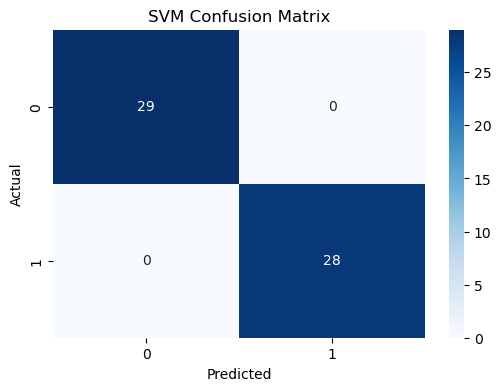

In [38]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("SVM Confusion Matrix")

plt.show()

In [39]:
final_df.to_csv("data/final_dataset.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!


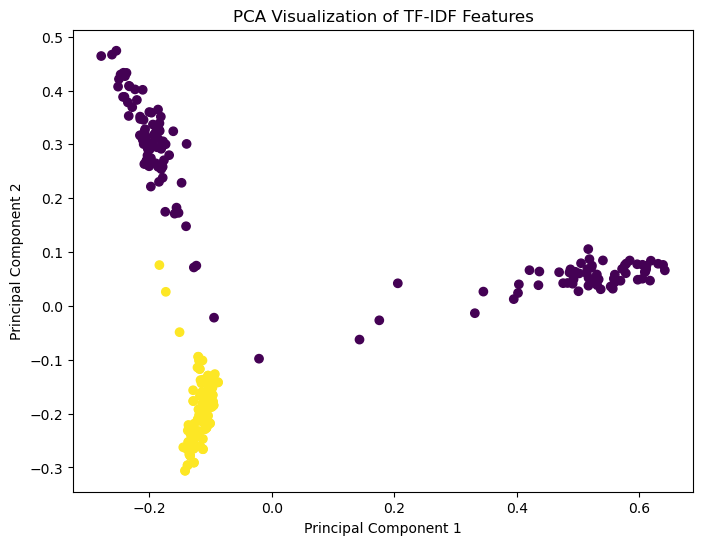

In [40]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X_dense = X.toarray()

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_dense)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y
)

plt.title("PCA Visualization of TF-IDF Features")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.show()

<u><h1> Word2Vec Embedding</h1></u>

In [41]:
final_df["tokens"] = final_df["cleaned_text"].apply(
    lambda x: x.split()
)

In [42]:
from gensim.models import Word2Vec

w2v_model = Word2Vec(
    sentences=final_df["tokens"],
    vector_size=100,
    window=5,
    min_count=1,
    workers=4
)

In [43]:
import numpy as np

def document_vector(tokens):
    vectors = [
        w2v_model.wv[word]
        for word in tokens
        if word in w2v_model.wv
    ]

    if len(vectors) == 0:
        return np.zeros(100)

    return np.mean(vectors, axis=0)

X_w2v = np.array(
    [document_vector(tokens)
     for tokens in final_df["tokens"]]
)

y_w2v = final_df["generated"]

In [44]:
print(X_w2v.shape)

(282, 100)


In [45]:
from sklearn.model_selection import train_test_split

X_train_w2v, X_test_w2v, y_train_w2v, y_test_w2v = train_test_split(
    X_w2v,
    y_w2v,
    test_size=0.2,
    random_state=42
)

print(X_train_w2v.shape)
print(X_test_w2v.shape)

(225, 100)
(57, 100)


In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr_w2v = LogisticRegression(max_iter=1000)

lr_w2v.fit(X_train_w2v, y_train_w2v)

lr_pred = lr_w2v.predict(X_test_w2v)

print("Word2Vec + Logistic Regression Accuracy:",
      accuracy_score(y_test_w2v, lr_pred))

print(classification_report(y_test_w2v, lr_pred))

Word2Vec + Logistic Regression Accuracy: 0.8245614035087719
              precision    recall  f1-score   support

           0       0.85      0.79      0.82        29
           1       0.80      0.86      0.83        28

    accuracy                           0.82        57
   macro avg       0.83      0.83      0.82        57
weighted avg       0.83      0.82      0.82        57



In [47]:
from sklearn.svm import SVC

svm_w2v = SVC()

svm_w2v.fit(X_train_w2v, y_train_w2v)

svm_pred = svm_w2v.predict(X_test_w2v)

print("Word2Vec + SVM Accuracy:",
      accuracy_score(y_test_w2v, svm_pred))

print(classification_report(y_test_w2v, svm_pred))

Word2Vec + SVM Accuracy: 0.8596491228070176
              precision    recall  f1-score   support

           0       0.92      0.79      0.85        29
           1       0.81      0.93      0.87        28

    accuracy                           0.86        57
   macro avg       0.87      0.86      0.86        57
weighted avg       0.87      0.86      0.86        57



In [48]:
from sklearn.ensemble import RandomForestClassifier

rf_w2v = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_w2v.fit(X_train_w2v, y_train_w2v)

rf_pred = rf_w2v.predict(X_test_w2v)

print("Word2Vec + Random Forest Accuracy:",
      accuracy_score(y_test_w2v, rf_pred))

print(classification_report(y_test_w2v, rf_pred))

Word2Vec + Random Forest Accuracy: 0.9649122807017544
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        29
           1       0.96      0.96      0.96        28

    accuracy                           0.96        57
   macro avg       0.96      0.96      0.96        57
weighted avg       0.96      0.96      0.96        57



In [53]:
import pandas as pd

comparison = pd.DataFrame({
    "Embedding": [
        "TF-IDF",
        "TF-IDF",
        "Word2Vec",
        "Word2Vec",
        "Word2Vec"
    ],

    "Model": [
        "Logistic Regression",
        "SVM",
        "Logistic Regression",
        "SVM",
        "Random Forest"
    ],

    "Accuracy": [
        tfidf_lr_acc,
        tfidf_svm_acc,
        accuracy_score(y_test_w2v, lr_pred),
        accuracy_score(y_test_w2v, svm_pred),
        accuracy_score(y_test_w2v, rf_pred)
    ]
})

print(comparison)
       

  Embedding                Model  Accuracy
0    TF-IDF  Logistic Regression  1.000000
1    TF-IDF                  SVM  1.000000
2  Word2Vec  Logistic Regression  0.824561
3  Word2Vec                  SVM  1.000000
4  Word2Vec        Random Forest  0.964912


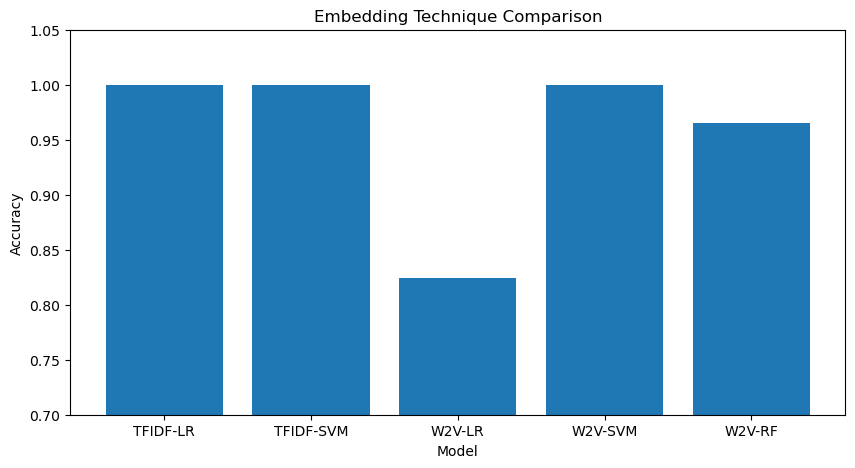

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

labels = [
    "TFIDF-LR",
    "TFIDF-SVM",
    "W2V-LR",
    "W2V-SVM",
    "W2V-RF"
]

scores = [
    1.0,
    1.0,
    0.824561,
    1.0,
    0.964912
]

plt.bar(labels, scores)

plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.title("Embedding Technique Comparison")

plt.ylim(0.7, 1.05)

plt.show()